Polynomial Features + Regularization
**Goal:**
1. Apply Polynomial Features on a real dataset
2. Increase model complexity
3. Compare Linear Regression and Ridge Regression
4. Observe why regularization becomes important

In [60]:
# Import required libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    PolynomialFeatures
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

import matplotlib.pyplot as plt

In [61]:
# Load California Housing Dataset

df = pd.read_csv("housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [62]:
# Basic dataset information

print("Shape:", df.shape)

df.info()

Shape: (20640, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [63]:
# Keep only numerical columns
# Fill missing values if present

df_num = df.select_dtypes(include=np.number)

df_num = df_num.fillna(df_num.mean())

df_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [64]:
# Separate features and target

X = df_num.drop(
    "median_house_value",
    axis=1
)

y = df_num["median_house_value"]

In [65]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
# Scale features before creating polynomial features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [67]:
# Create polynomial features
# degree=2 creates squared terms and interaction terms

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(
    X_train_scaled
)

X_test_poly = poly.transform(
    X_test_scaled
)

In [68]:
# Observe feature explosion

print("Original Shape :", X_train_scaled.shape)

print("Polynomial Shape :", X_train_poly.shape)

Original Shape : (16512, 8)
Polynomial Shape : (16512, 44)


In [69]:
# Train Linear Regression on polynomial features

lr = LinearRegression()

lr.fit(
    X_train_poly,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [70]:
# Predict using Linear Regression

lr_pred = lr.predict(
    X_test_poly
)

In [71]:
# Evaluate Linear Regression

lr_r2 = r2_score(
    y_test,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

print("Linear Regression")
print("R2 Score :", lr_r2)
print("RMSE :", lr_rmse)

Linear Regression
R2 Score : 0.6506826259019096
RMSE : 67657.12255732376


In [72]:
# Train Ridge Regression
# Regularization helps control large coefficients

ridge = Ridge(alpha=10)

ridge.fit(
    X_train_poly,
    y_train
)

,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [73]:
# Predict using Ridge Regression

ridge_pred = ridge.predict(
    X_test_poly
)

In [74]:
# Evaluate Ridge Regression

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_pred
    )
)

print("Ridge Regression")
print("R2 Score :", ridge_r2)
print("RMSE :", ridge_rmse)

Ridge Regression
R2 Score : 0.6514340255611433
RMSE : 67584.31640654257


In [75]:
# Compare model performance

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "R2 Score": [
        lr_r2,
        ridge_r2
    ],
    "RMSE": [
        lr_rmse,
        ridge_rmse
    ]
})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.650683,67657.122557
1,Ridge Regression,0.651434,67584.316407


In [76]:
# Compare train and test performance
# Helps identify overfitting

print("Linear Regression")
print("Train R2 :", lr.score(X_train_poly, y_train))
print("Test R2  :", lr.score(X_test_poly, y_test))

print("\n-----------------\n")

print("Ridge Regression")
print("Train R2 :", ridge.score(X_train_poly, y_train))
print("Test R2  :", ridge.score(X_test_poly, y_test))

Linear Regression
Train R2 : 0.7016270276689182
Test R2  : 0.6506826259019096

-----------------

Ridge Regression
Train R2 : 0.7013596850531223
Test R2  : 0.6514340255611433


In [77]:
# Compare coefficient magnitudes

print(
    "Largest Linear Coefficient:",
    np.max(np.abs(lr.coef_))
)

print(
    "Largest Ridge Coefficient:",
    np.max(np.abs(ridge.coef_))
)

Largest Linear Coefficient: 128111.80441153007
Largest Ridge Coefficient: 124132.1046048253


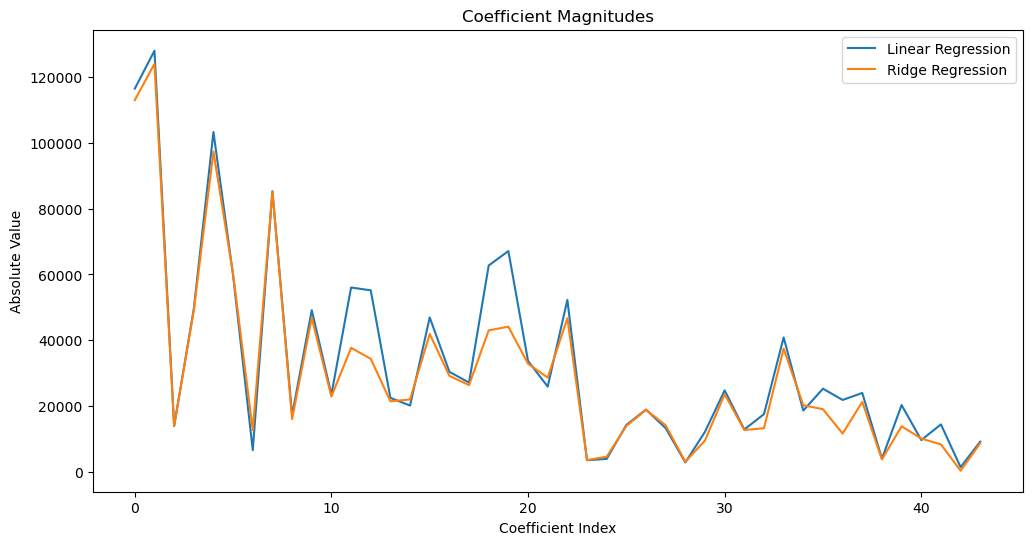

In [78]:
# Visualize coefficient shrinkage

plt.figure(figsize=(12,6))

plt.plot(
    np.abs(lr.coef_),
    label="Linear Regression"
)

plt.plot(
    np.abs(ridge.coef_),
    label="Ridge Regression"
)

plt.xlabel("Coefficient Index")
plt.ylabel("Absolute Value")

plt.title(
    "Coefficient Magnitudes"
)

plt.legend()

plt.show()

In [ ]:
# Create feature names for polynomial features

feature_names = poly.get_feature_names_out(
    X.columns
)

coef_df = pd.DataFrame({
    
    "Feature": feature_names,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_
})

coef_df.head()

,Feature,Linear,Ridge
0,longitude,-116565.933031,-113072.100569
1,latitude,-128111.804412,-124132.104605
2,housing_median_age,13841.086898,13890.567688
3,total_rooms,-49470.914504,-49004.589027
4,total_bedrooms,103366.684105,97417.176235


In [80]:
# Most influential features according to Ridge

coef_df["Abs_Ridge"] = np.abs(
    coef_df["Ridge"]
)

coef_df.sort_values(
    "Abs_Ridge",
    ascending=False
).head(10)

,Feature,Linear,Ridge,Abs_Ridge
1,latitude,-128111.804412,-124132.104605,124132.104605
0,longitude,-116565.933031,-113072.100569,113072.100569
4,total_bedrooms,103366.684105,97417.176235,97417.176235
7,median_income,85351.342811,85297.875957,85297.875957
5,population,-59712.822810,-60031.521860,60031.521860
3,total_rooms,-49470.914504,-49004.589027,49004.589027
9,longitude latitude,49117.679567,46781.817116,46781.817116
22,latitude median_income,-52269.142206,-46683.545636,46683.545636
19,latitude total_bedrooms,-67129.231806,-44095.462173,44095.462173
18,latitude total_rooms,62726.608740,42982.478824,42982.478824


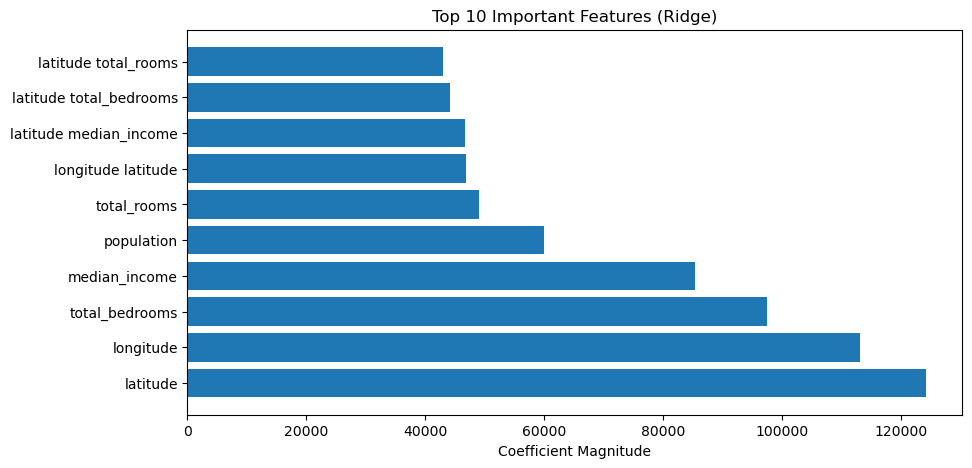

In [81]:
top_features = coef_df.sort_values(
    "Abs_Ridge",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_features["Feature"],
    top_features["Abs_Ridge"]
)

plt.title(
    "Top 10 Important Features (Ridge)"
)

plt.xlabel("Coefficient Magnitude")

plt.show()

In [82]:
# Ridge rarely makes coefficients exactly zero

print(
    "Number of Zero Coefficients:",
    np.sum(ridge.coef_ == 0)
)

Number of Zero Coefficients: 0


# Observations

- Polynomial Features increased the feature count from 8 to 44.
- This increased model complexity.
- Linear Regression and Ridge achieved similar R² scores.
- Ridge slightly improved test performance.
- Ridge reduced coefficient magnitudes.
- Regularization helped control model complexity.
- Regularization becomes more important as feature count increases.